# Import Libraries

In [1]:
import re
import string
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve, auc
)

from nltk.stem import PorterStemmer

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")

Libraries loaded successfully.


# Load the Dataset

In [2]:
import os

DATA_PATH = "spam.csv"  # <-- change this to point to your own dataset if you have one

def generate_synthetic_dataset(n_per_class=500, seed=RANDOM_STATE):
    """Generates a synthetic spam/ham email dataset for demonstration purposes.
    Real datasets (e.g. the SMS Spam Collection or Kaggle Spam Email Dataset) can be
    swapped in via DATA_PATH.
    """
    rng = np.random.RandomState(seed)

    spam_templates = [
        "CONGRATULATIONS! You have WON a ${amount} prize! Click here now to claim before it expires!",
        "URGENT: Your account will be suspended! Verify your password immediately at this link.",
        "Get RICH quick! Make ${amount} a week working from home, no experience needed, click now!",
        "FREE offer just for you! Claim your free {item} today, limited time only, act fast!!!",
        "You have been selected to receive a FREE {item}! Confirm your shipping details now.",
        "Hot singles in your area want to chat with you now! Click here to meet them tonight!",
        "Your loan of ${amount} has been PRE-APPROVED! No credit check required, apply now!",
        "LIMITED TIME: Buy one {item} get one FREE! Order now before this deal disappears!",
        "Dear winner, your email was selected in our lottery draw for ${amount}, claim now!",
        "Lose weight fast with this ONE weird trick! Doctors are shocked, buy now and save!",
        "Act now! Your subscription payment of ${amount} failed, update your card details here.",
        "You've earned {amount} reward points! Redeem them now before they expire tonight!",
    ]

    ham_templates = [
        "Hi, just checking in about the {item} meeting scheduled for next week, let me know if it works.",
        "Thanks for sending over the report, I'll review the {item} section and get back to you tomorrow.",
        "Can we reschedule our call to discuss the {item} project? I have a conflict at the original time.",
        "Please find attached the invoice for {item} services rendered last month, let me know if you have questions.",
        "Hey, are we still on for lunch to talk about the {item} proposal this Friday?",
        "I wanted to follow up on the {item} order, could you confirm the delivery date?",
        "Reminder: our team meeting about the {item} roadmap is at 10am tomorrow in the main conference room.",
        "Attached is the updated {item} document with the changes we discussed yesterday.",
        "Hope you're doing well! Just wanted to check if you received the {item} samples we sent last week.",
        "Could you review the {item} budget spreadsheet and send feedback by end of day?",
        "Thank you for your email regarding the {item} account, I've forwarded it to our billing team.",
        "Looking forward to catching up about the {item} presentation during our one-on-one next Tuesday.",
    ]

    items = ["laptop", "gift card", "vacation package", "iPhone", "watch", "software license",
             "project", "quarterly", "marketing", "onboarding", "vendor", "product"]
    amounts = ["500", "1,000", "2,500", "10,000", "250", "5,000"]

    rows = []
    for _ in range(n_per_class):
        template = spam_templates[rng.randint(len(spam_templates))]
        text = template.format(item=items[rng.randint(len(items))],
                                amount=amounts[rng.randint(len(amounts))])
        rows.append({"text": text, "label": "spam"})

    for _ in range(n_per_class):
        template = ham_templates[rng.randint(len(ham_templates))]
        text = template.format(item=items[rng.randint(len(items))])
        rows.append({"text": text, "label": "ham"})

    df = pd.DataFrame(rows)
    df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return df


if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded dataset from '{DATA_PATH}' with shape {df.shape}")
else:
    print(f"'{DATA_PATH}' not found - generating a synthetic sample dataset for demonstration.")
    df = generate_synthetic_dataset(n_per_class=500)
    print(f"Synthetic dataset created with shape {df.shape}")

df.head()

'spam.csv' not found - generating a synthetic sample dataset for demonstration.
Synthetic dataset created with shape (1000, 2)


,text,label
0,Reminder: our team meeting about the onboardin...,ham
1,"I wanted to follow up on the onboarding order,...",ham
2,Thank you for your email regarding the gift ca...,ham
3,"Thanks for sending over the report, I'll revie...",ham
4,You have been selected to receive a FREE marke...,spam


# Exploratory Data Analysis (EDA)

In [3]:
print("Dataset shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nLabel distribution:\n", df['label'].value_counts())

Dataset shape: (1000, 2)

Missing values:
 text     0
label    0
dtype: int64

Label distribution:
 label
ham     500
spam    500
Name: count, dtype: int64


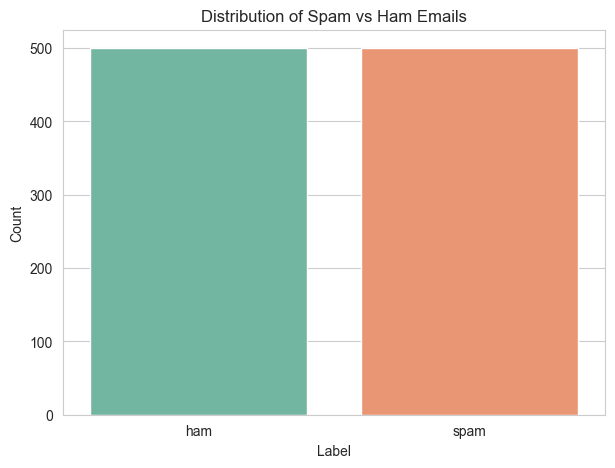

In [4]:
plt.figure()
sns.countplot(data=df, x="label", hue="label", palette="Set2", legend=False)
plt.title("Distribution of Spam vs Ham Emails")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

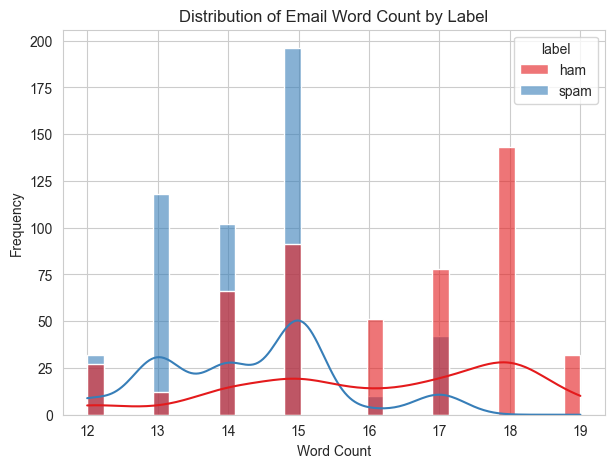

count    1000.000000
mean       15.253000
std         1.870425
min        12.000000
25%        14.000000
50%        15.000000
75%        17.000000
max        19.000000
Name: text_length, dtype: float64

In [5]:
df["text_length"] = df["text"].apply(lambda x: len(str(x).split()))

plt.figure()
sns.histplot(data=df, x="text_length", hue="label", bins=30, kde=True, palette="Set1", alpha=0.6)
plt.title("Distribution of Email Word Count by Label")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

df["text_length"].describe()

# Text Preprocessing (NLP)

In [6]:
stemmer = PorterStemmer()
STOPWORDS = set(ENGLISH_STOP_WORDS)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)          # remove URLs
    text = re.sub(r"\S+@\S+", " ", text)                            # remove email addresses
    text = re.sub(r"<.*?>", " ", text)                               # remove HTML tags
    text = re.sub(r"[^a-z\s]", " ", text)                            # remove punctuation & numbers
    text = re.sub(r"\s+", " ", text).strip()                         # remove extra whitespace

    tokens = text.split()
    tokens = [word for word in tokens if word not in STOPWORDS and len(word) > 2]
    tokens = [stemmer.stem(word) for word in tokens]

    return " ".join(tokens)


df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text", "label"]].head()

,text,clean_text,label
0,Reminder: our team meeting about the onboardin...,remind team meet onboard roadmap tomorrow main...,ham
1,"I wanted to follow up on the onboarding order,...",want follow onboard order confirm deliveri date,ham
2,Thank you for your email regarding the gift ca...,thank email regard gift card account forward b...,ham
3,"Thanks for sending over the report, I'll revie...",thank send report review gift card section tom...,ham
4,You have been selected to receive a FREE marke...,select receiv free market confirm ship detail,spam


# Train / Test Split

In [7]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

Training samples: 800
Testing samples:  200


# Feature Extraction with TF-IDF

In [8]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF training matrix shape:", X_train_tfidf.shape)
print("TF-IDF testing matrix shape: ", X_test_tfidf.shape)

TF-IDF training matrix shape: (800, 592)
TF-IDF testing matrix shape:  (200, 592)


# Model Training

In [9]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

svm_base = LinearSVC(random_state=RANDOM_STATE)
svm_model = CalibratedClassifierCV(svm_base, cv=5)
svm_model.fit(X_train_tfidf, y_train)

print("Both models trained successfully.")

Both models trained successfully.


# Model Evaluation

===== Naive Bayes =====
Accuracy : 1.0000
F1-Score : 1.0000
Precision: 1.0000
Recall   : 1.0000

Classification Report:
               precision    recall  f1-score   support

         ham       1.00      1.00      1.00       100
        spam       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



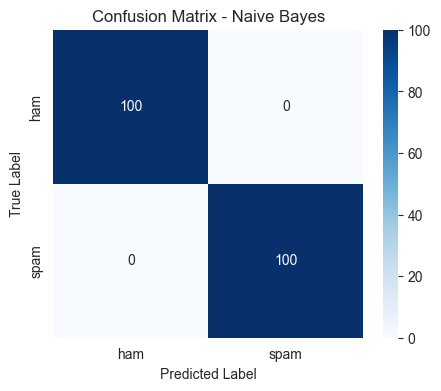

In [10]:
def evaluate_model(model, name, X_test_vec, y_test):
    y_pred = model.predict(X_test_vec)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label="spam")
    precision = precision_score(y_test, y_pred, pos_label="spam")
    recall = recall_score(y_test, y_pred, pos_label="spam")

    print(f"===== {name} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    return {"model": name, "accuracy": acc, "f1_score": f1,
            "precision": precision, "recall": recall}


nb_results = evaluate_model(nb_model, "Naive Bayes", X_test_tfidf, y_test)

===== SVM (Linear) =====
Accuracy : 1.0000
F1-Score : 1.0000
Precision: 1.0000
Recall   : 1.0000

Classification Report:
               precision    recall  f1-score   support

         ham       1.00      1.00      1.00       100
        spam       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



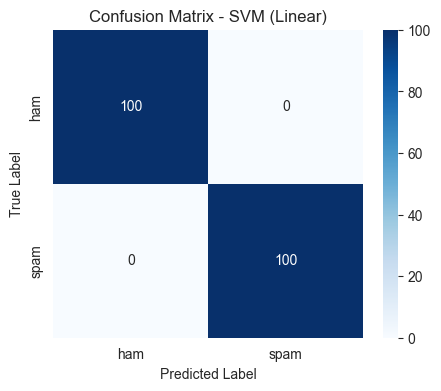

In [11]:
svm_results = evaluate_model(svm_model, "SVM (Linear)", X_test_tfidf, y_test)

# Model Comparison

,accuracy,f1_score,precision,recall
model,,,,
Naive Bayes,1.0,1.0,1.0,1.0
SVM (Linear),1.0,1.0,1.0,1.0


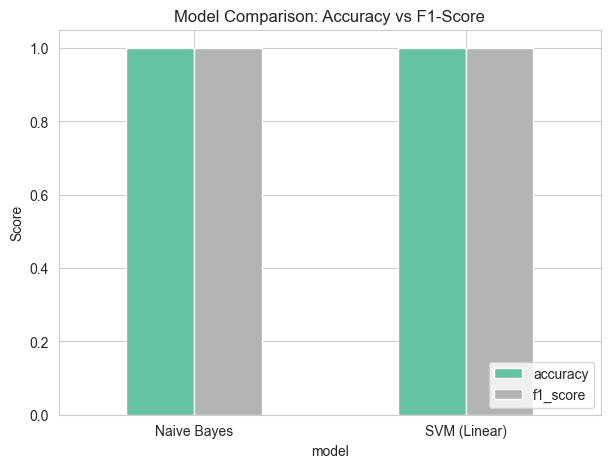


Best performing model based on F1-Score: Naive Bayes


In [12]:
results_df = pd.DataFrame([nb_results, svm_results]).set_index("model")
display(results_df)

results_df[["accuracy", "f1_score"]].plot(kind="bar", figsize=(7, 5), colormap="Set2")
plt.title("Model Comparison: Accuracy vs F1-Score")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.show()

best_model_name = results_df["f1_score"].idxmax()
best_model = nb_model if best_model_name == "Naive Bayes" else svm_model
print(f"\nBest performing model based on F1-Score: {best_model_name}")

# ROC Curve Comparison

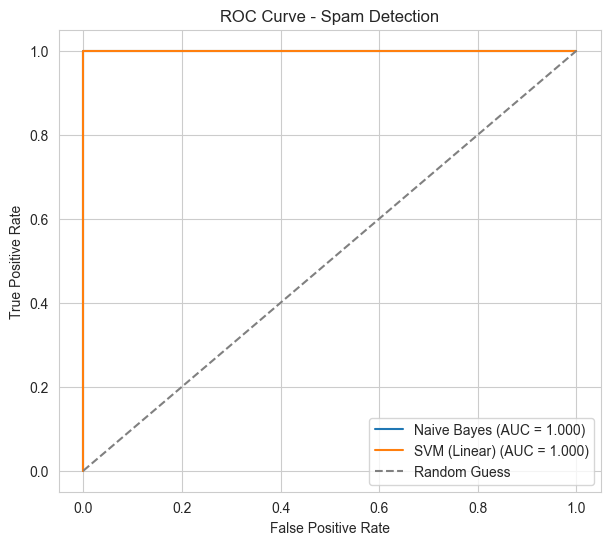

In [13]:
plt.figure(figsize=(7, 6))

for model, name in [(nb_model, "Naive Bayes"), (svm_model, "SVM (Linear)")]:
    y_proba = model.predict_proba(X_test_tfidf)[:, list(model.classes_).index("spam")]
    y_test_binary = (y_test == "spam").astype(int)
    fpr, tpr, _ = roc_curve(y_test_binary, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Spam Detection")
plt.legend(loc="lower right")
plt.show()

# Cross-Validation (Robustness Check)

In [14]:
X_full_tfidf = tfidf.transform(df["clean_text"])
y_full = df["label"]

cv_scores = cross_val_score(best_model, X_full_tfidf, y_full, cv=5, scoring="f1_macro")

print("Cross-validation F1 (macro) scores:", np.round(cv_scores, 4))
print(f"Mean F1 (macro): {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

Cross-validation F1 (macro) scores: [1. 1. 1. 1. 1.]
Mean F1 (macro): 1.0000  |  Std: 0.0000


# Display Predicted Category for New Emails

In [15]:
def predict_email(text, model=best_model, vectorizer=tfidf):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    proba = model.predict_proba(vec)[0]
    classes = model.classes_
    confidence = {str(cls): float(round(p, 3)) for cls, p in zip(classes, proba)}
    return pred, confidence


sample_emails = [
    "CONGRATULATIONS! You've won a $5,000 gift card, click this link now to claim your prize!!!",
    "Hi team, attached is the updated budget spreadsheet for the marketing project, let me know your thoughts.",
    "URGENT: Your account password has expired, verify your details immediately to avoid suspension.",
    "Hey, are we still meeting tomorrow at 10am to discuss the quarterly roadmap?",
]

print(f"{'EMAIL':<90} {'PREDICTED':<12} CONFIDENCE")
print("-" * 130)
for email in sample_emails:
    pred, confidence = predict_email(email)
    display_text = (email[:85] + "...") if len(email) > 85 else email
    print(f"{display_text:<90} {pred.upper():<12} {confidence}")

EMAIL                                                                                      PREDICTED    CONFIDENCE
----------------------------------------------------------------------------------------------------------------------------------
CONGRATULATIONS! You've won a $5,000 gift card, click this link now to claim your pri...   SPAM         {'ham': 0.007, 'spam': 0.993}
Hi team, attached is the updated budget spreadsheet for the marketing project, let me...   HAM          {'ham': 0.999, 'spam': 0.001}
URGENT: Your account password has expired, verify your details immediately to avoid s...   SPAM         {'ham': 0.003, 'spam': 0.997}
Hey, are we still meeting tomorrow at 10am to discuss the quarterly roadmap?               HAM          {'ham': 0.988, 'spam': 0.012}


In [16]:
results_table = []
for email in sample_emails:
    pred, confidence = predict_email(email)
    results_table.append({
        "email": (email[:70] + "...") if len(email) > 70 else email,
        "predicted_category": pred.upper(),
        "spam_confidence": confidence.get("spam", 0),
        "ham_confidence": confidence.get("ham", 0),
    })

results_table_df = pd.DataFrame(results_table)
display(results_table_df)

,email,predicted_category,spam_confidence,ham_confidence
0,"CONGRATULATIONS! You've won a $5,000 gift card...",SPAM,0.993,0.007
1,"Hi team, attached is the updated budget spread...",HAM,0.001,0.999
2,"URGENT: Your account password has expired, ver...",SPAM,0.997,0.003
3,"Hey, are we still meeting tomorrow at 10am to ...",HAM,0.012,0.988
